In [5]:
import sys
import os
sys.path.append(os.getcwd())

In [6]:
from tsp import Place, build_tourist_route

Пример работы алгоритма с ограничениями
--

In [15]:
coords = {
    0: (0, 0),   # отель
    1: (1, 2),   # Музей истории
    2: (2, 3),   # Кафе Чак-чак
    3: (1, 4),   # Памятник паровозу
    4: (4, 3),   # Ресторан Казани
    5: (5, 2),   # Центр развития Казани
    6: (3, 1),   # Зеленый парк
}

In [16]:

places = [
        Place(0, "Старт: отель", "start", 0.0, 0.0),
        Place(1, "Музей истории", "museum", 0.0, 1),
        Place(2, "Кафе Чак-Чак", "cafe", 500.0, 0.5),
        Place(3, "Памятник паровозу", "attraction", 0.0, 0.5),
        Place(4, "Ресторан Казани", "restaurant", 1200.0, 1.16),
        Place(5, "Центр развития Казани", "historic_site", 400.0, 0.25),
        Place(6, "Зеленый парк", "park", 0.0, 0.6),
    ]

dist = [
        [0.0, 1.2, 1.0, 0.5, 2.0, 2.3, 1.5],
        [1.2, 0.0, 0.6, 1.0, 1.5, 1.8, 1.0],
        [1.0, 0.6, 0.0, 1.1, 1.4, 2.0, 1.3],
        [0.5, 1.0, 1.1, 0.0, 2.1, 2.4, 1.6],
        [2.0, 1.5, 1.4, 2.1, 0.0, 1.0, 1.3],
        [2.3, 1.8, 2.0, 2.4, 1.0, 0.0, 0.9],
        [1.5, 1.0, 1.3, 1.6, 1.3, 0.9, 0.0],
    ]

result = build_tourist_route(
    dist=dist,
    places=places,
    start_index=0,
    max_time_hours=5.0,
    max_budget=5000.0,
    speed_kmh=5.0,
)



print("Итоговый маршрут:", result["route_names"])
print("Итоговая стоимость:", round(result["total_cost"], 2))
print("Итоговое время:", round(result["total_time_hours"], 2))
print("Правило еды выполнено:", result["food_rule_ok"])

Итоговый маршрут: ['Старт: отель', 'Кафе Чак-Чак', 'Зеленый парк', 'Ресторан Казани', 'Музей истории', 'Памятник паровозу']
Итоговая стоимость: 1700.0
Итоговое время: 4.98
Правило еды выполнено: True


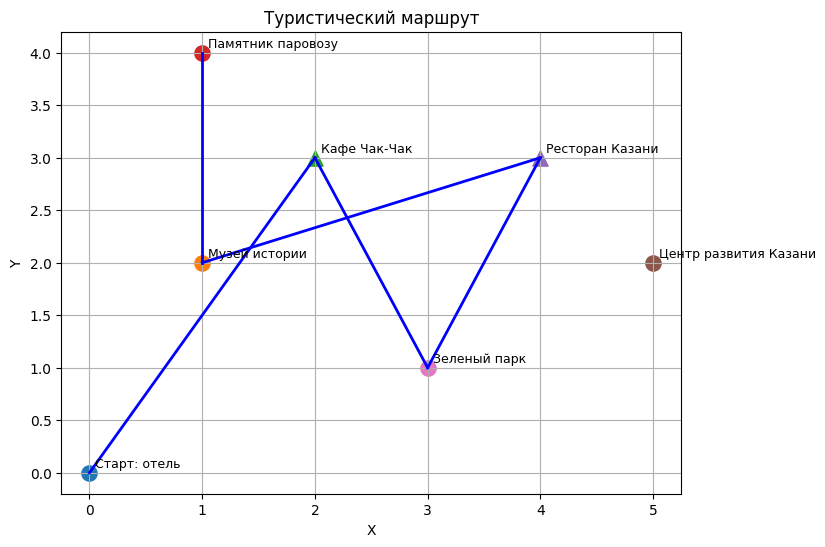

In [17]:
import matplotlib.pyplot as plt

route = result["route_indices"]

plt.figure(figsize=(8, 6))

for place in places:
    x, y = coords[place.id]
    
    if place.category in {"cafe", "restaurant"}:
        marker = "^"
    else:
        marker = "o"
    
    plt.scatter(x, y, s=120, marker=marker)
    plt.text(x + 0.05, y + 0.05, place.name, fontsize=9)

for i in range(len(route) - 1):
    x1, y1 = coords[route[i]]
    x2, y2 = coords[route[i + 1]]
    plt.plot([x1, x2], [y1, y2], linewidth=2, color='blue')

plt.title("Туристический маршрут")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()